In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("pharmacy_inventory_daily_raw_30_products_600_days.csv")

In [ ]:
# =========================
# BASIC INVENTORY FLOW
# =========================
# ending_stock is needed for later engineered features
df["ending_stock"] = df["opening_stock"] + df["received_qty"] - df["sold_qty"]

# Safety cleanup
df["ending_stock"] = df["ending_stock"].clip(lower=0)

In [ ]:
# =========================
# FEATURE: avg_sales_7d
# =========================
# Rolling average of sold_qty per product
df["avg_sales_7d"] = (
    df.groupby("product_id")["sold_qty"]
      .rolling(window=7, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

In [ ]:
# =========================
# FEATURE: avg_sales_7d
# =========================
# Rolling average of sold_qty per product
df["avg_sales_7d"] = (
    df.groupby("product_id")["sold_qty"]
      .rolling(window=7, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

In [ ]:
# =========================
# FEATURE: required_stock
# =========================
# Required stock to cover expected demand during lead time
df["required_stock"] = df["avg_sales_7d"] * df["lead_time_days"]

In [ ]:
# =========================
# FEATURE: avg_remaining_shelf_life_days
# =========================
# Since batch-level expiry is not available, we estimate average remaining shelf life
# using a weighted freshness update per product over time.
#
# Logic:
# - Existing stock gets 1 day older each day
# - Newly received stock is assumed fresh, so its remaining shelf life starts at shelf_life_days
# - Daily average remaining shelf life is the weighted average of:
#     aged previous stock + fresh received stock

def estimate_avg_remaining_shelf_life(group):
    group = group.sort_values("date").copy()

    avg_remaining_list = []

    prev_ending_stock = None
    prev_avg_remaining = None

    for i, row in group.iterrows():
        opening_stock = row["opening_stock"]
        received_qty = row["received_qty"]
        shelf_life_days = row["shelf_life_days"]

        # First row of each product
        if prev_ending_stock is None:
            # Assume initial opening stock is not perfectly fresh.
            # Start it at 70% of full shelf life for realism.
            opening_avg_remaining = shelf_life_days * 0.70
        else:
            # Existing stock ages by 1 day from previous day's estimate
            opening_avg_remaining = max(prev_avg_remaining - 1, 0)

        total_available_stock = opening_stock + received_qty

        if total_available_stock > 0:
            weighted_remaining = (
                (opening_stock * opening_avg_remaining) +
                (received_qty * shelf_life_days)
            ) / total_available_stock
        else:
            weighted_remaining = 0

        # After sales, we assume sales consume stock proportionally
        # so the average remaining shelf life stays approximately the same
        avg_remaining_today = max(weighted_remaining, 0)

        avg_remaining_list.append(avg_remaining_today)

        prev_ending_stock = row["ending_stock"]
        prev_avg_remaining = avg_remaining_today

    group["avg_remaining_shelf_life_days"] = avg_remaining_list
    return group

df = (
    df.groupby("product_id", group_keys=False)
      .apply(estimate_avg_remaining_shelf_life)
      .reset_index(drop=True)
)

/tmp/ipykernel_7581/2217288738.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_avg_remaining_shelf_life)


In [ ]:
import numpy as np

safe_avg_sales = df["avg_sales_7d"].replace(0, np.nan)

df["days_to_sell_inventory"] = df["ending_stock"] / safe_avg_sales
df["days_to_sell_inventory"] = df["days_to_sell_inventory"].replace([np.inf, -np.inf], np.nan)
df["days_to_sell_inventory"] = df["days_to_sell_inventory"].fillna(0)

In [ ]:
# =========================
# OPTIONAL CLEANUP / ROUNDING
# =========================
df["avg_sales_7d"] = df["avg_sales_7d"].round(2)
df["required_stock"] = df["required_stock"].round(2)
df["days_to_sell_inventory"] = df["days_to_sell_inventory"].round(2)
df["avg_remaining_shelf_life_days"] = df["avg_remaining_shelf_life_days"].round(2)

In [ ]:
# =========================
# CHECK OUTPUT
# =========================
print(df.head(15))
print(df[[
    "date", "product_id", "product_name", "category",
    "opening_stock", "received_qty", "sold_qty", "ending_stock",
    "avg_sales_7d", "required_stock",
    "days_to_sell_inventory", "avg_remaining_shelf_life_days"
]].sample(10, random_state=42))

          date product_id               product_name     category  \
0   2025-01-01       P001  Amoxicillin 500mg Capsule  antibiotics   
1   2025-01-02       P001  Amoxicillin 500mg Capsule  antibiotics   
2   2025-01-03       P001  Amoxicillin 500mg Capsule  antibiotics   
3   2025-01-04       P001  Amoxicillin 500mg Capsule  antibiotics   
4   2025-01-05       P001  Amoxicillin 500mg Capsule  antibiotics   
5   2025-01-06       P001  Amoxicillin 500mg Capsule  antibiotics   
6   2025-01-07       P001  Amoxicillin 500mg Capsule  antibiotics   
7   2025-01-08       P001  Amoxicillin 500mg Capsule  antibiotics   
8   2025-01-09       P001  Amoxicillin 500mg Capsule  antibiotics   
9   2025-01-10       P001  Amoxicillin 500mg Capsule  antibiotics   
10  2025-01-11       P001  Amoxicillin 500mg Capsule  antibiotics   
11  2025-01-12       P001  Amoxicillin 500mg Capsule  antibiotics   
12  2025-01-13       P001  Amoxicillin 500mg Capsule  antibiotics   
13  2025-01-14       P001  Amoxici

In [ ]:
# =========================
# SAVE ENGINEERED DATASET
# =========================
df.to_csv("pharmacy_inventory_feature_engineered.csv", index=False)

print("\nSaved file: pharmacy_inventory_feature_engineered.csv")


Saved file: pharmacy_inventory_feature_engineered.csv


# Basic Overview

In [ ]:
print(df.shape)
print(df.columns)
df.head()

(18000, 14)
Index(['date', 'product_id', 'product_name', 'category', 'opening_stock',
       'received_qty', 'sold_qty', 'lead_time_days', 'shelf_life_days',
       'ending_stock', 'avg_sales_7d', 'required_stock',
       'avg_remaining_shelf_life_days', 'days_to_sell_inventory'],
      dtype='object')


,date,product_id,product_name,category,opening_stock,received_qty,sold_qty,lead_time_days,shelf_life_days,ending_stock,avg_sales_7d,required_stock,avg_remaining_shelf_life_days,days_to_sell_inventory
0,2025-01-01,P001,Amoxicillin 500mg Capsule,antibiotics,50,0,22,3,730,28,22.00,66.00,511.0,1.27
1,2025-01-02,P001,Amoxicillin 500mg Capsule,antibiotics,28,0,25,3,730,3,23.50,70.50,510.0,0.13
2,2025-01-03,P001,Amoxicillin 500mg Capsule,antibiotics,3,0,3,3,730,0,16.67,50.00,509.0,0.00
3,2025-01-04,P001,Amoxicillin 500mg Capsule,antibiotics,0,100,19,3,730,81,17.25,51.75,730.0,4.70
4,2025-01-05,P001,Amoxicillin 500mg Capsule,antibiotics,81,0,23,3,730,58,18.40,55.20,729.0,3.15


# Data Types & Missing Values

In [ ]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           18000 non-null  object 
 1   product_id                     18000 non-null  object 
 2   product_name                   18000 non-null  object 
 3   category                       18000 non-null  object 
 4   opening_stock                  18000 non-null  int64  
 5   received_qty                   18000 non-null  int64  
 6   sold_qty                       18000 non-null  int64  
 7   lead_time_days                 18000 non-null  int64  
 8   shelf_life_days                18000 non-null  int64  
 9   ending_stock                   18000 non-null  int64  
 10  avg_sales_7d                   18000 non-null  float64
 11  required_stock                 18000 non-null  float64
 12  avg_remaining_shelf_life_days  18000 non-null 

,0
date,0
product_id,0
product_name,0
category,0
opening_stock,0
received_qty,0
sold_qty,0
lead_time_days,0
shelf_life_days,0
ending_stock,0


# Summary Statistics

In [ ]:
df.describe()

,opening_stock,received_qty,sold_qty,lead_time_days,shelf_life_days,ending_stock,avg_sales_7d,required_stock,avg_remaining_shelf_life_days,days_to_sell_inventory
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,51.591389,13.011444,13.019222,4.100000,826.333333,51.583611,13.020203,47.025148,816.750669,5.750980
std,42.813529,39.131513,10.445218,1.374811,220.965913,42.825748,9.801204,25.388087,222.041726,6.950662
min,0.000000,0.000000,0.000000,2.000000,365.000000,0.000000,1.000000,4.290000,0.000000,0.000000
25%,20.000000,0.000000,7.000000,3.000000,730.000000,20.000000,6.860000,29.140000,723.640000,1.960000
50%,41.000000,0.000000,11.000000,4.000000,730.000000,41.000000,11.000000,40.570000,728.000000,3.890000
75%,71.000000,0.000000,15.000000,5.000000,1095.000000,71.000000,15.430000,64.290000,1087.000000,6.260000
max,477.000000,540.000000,96.000000,7.000000,1095.000000,477.000000,70.290000,143.140000,1095.000000,75.000000


# Distribution of Key Variables

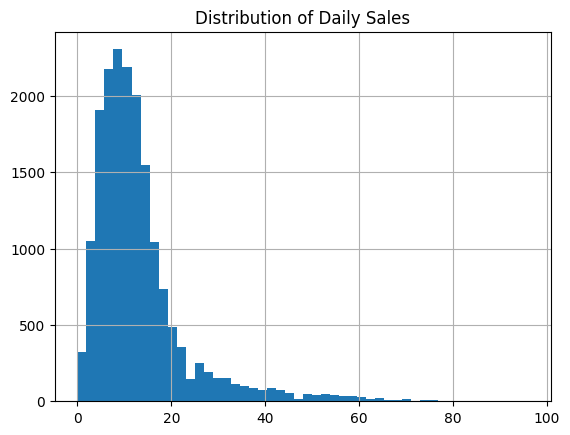

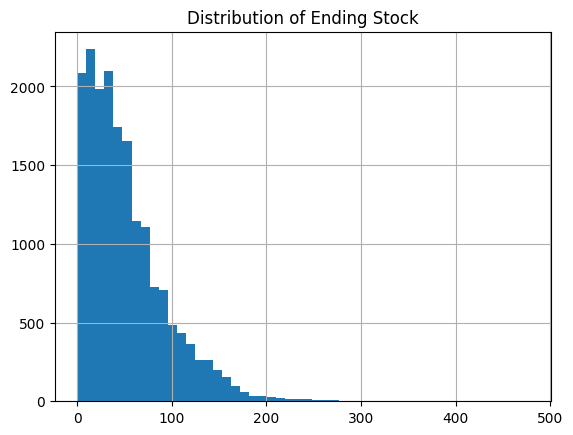

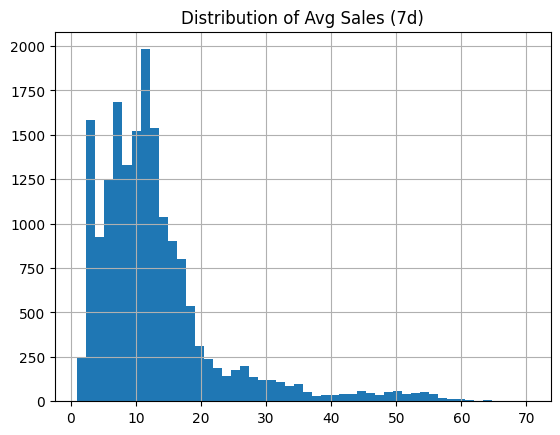

In [ ]:
import matplotlib.pyplot as plt

df["sold_qty"].hist(bins=50)
plt.title("Distribution of Daily Sales")
plt.show()

df["ending_stock"].hist(bins=50)
plt.title("Distribution of Ending Stock")
plt.show()

df["avg_sales_7d"].hist(bins=50)
plt.title("Distribution of Avg Sales (7d)")
plt.show()

# Time Series Check

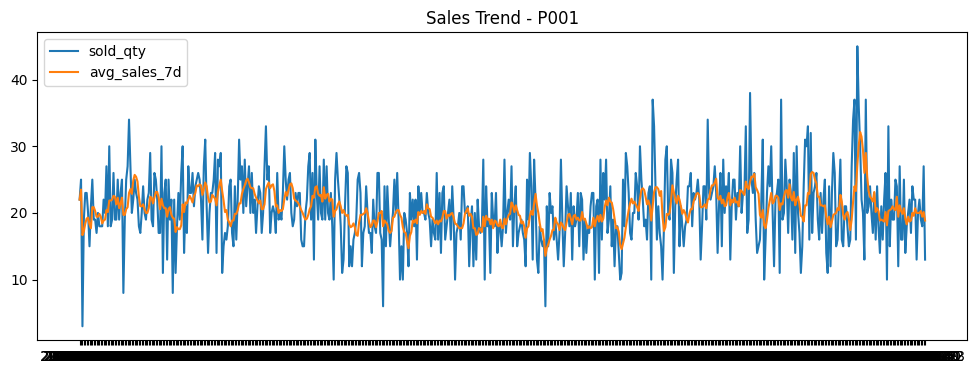

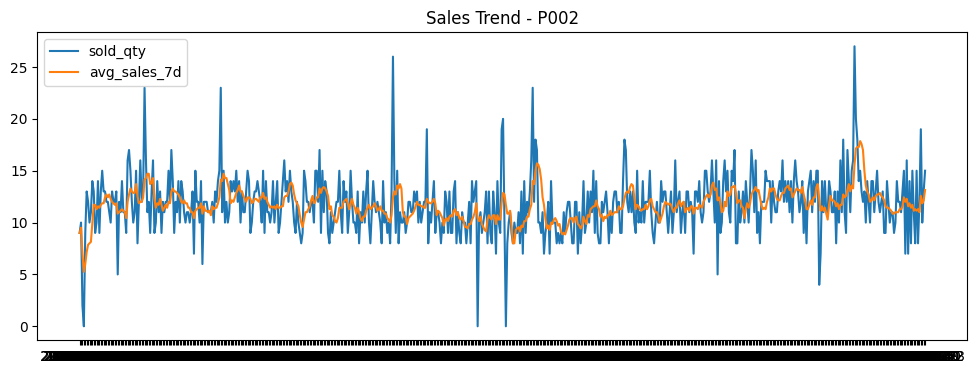

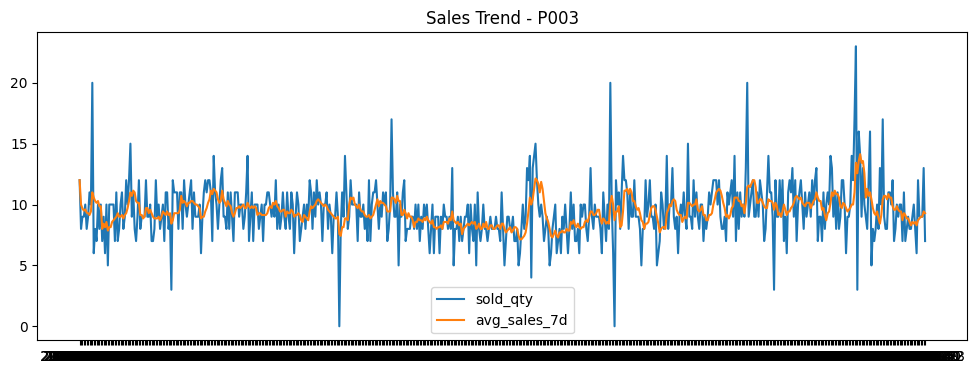

In [ ]:
sample_products = df["product_id"].unique()[:3]

for pid in sample_products:
    temp = df[df["product_id"] == pid]

    plt.figure(figsize=(12,4))
    plt.plot(temp["date"], temp["sold_qty"], label="sold_qty")
    plt.plot(temp["date"], temp["avg_sales_7d"], label="avg_sales_7d")
    plt.title(f"Sales Trend - {pid}")
    plt.legend()
    plt.show()

# Relationship Checks

## Demand vs Stock

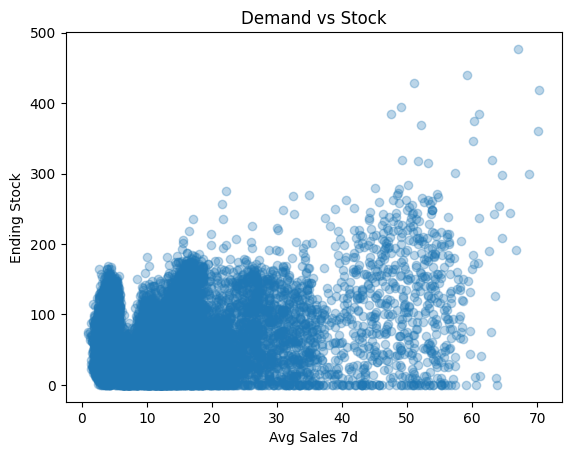

In [ ]:
plt.scatter(df["avg_sales_7d"], df["ending_stock"], alpha=0.3)
plt.xlabel("Avg Sales 7d")
plt.ylabel("Ending Stock")
plt.title("Demand vs Stock")
plt.show()

## Lead Time Impact

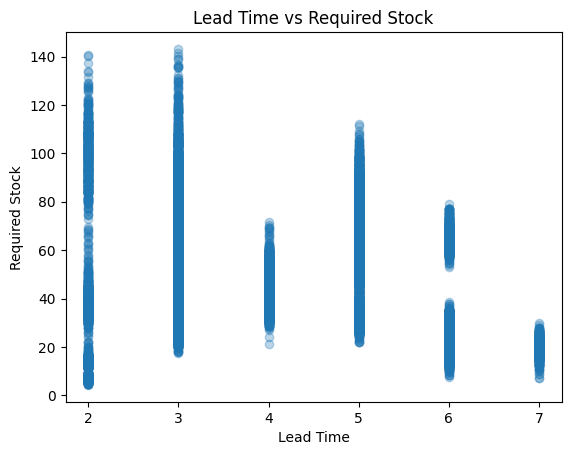

In [ ]:
plt.scatter(df["lead_time_days"], df["required_stock"], alpha=0.3)
plt.xlabel("Lead Time")
plt.ylabel("Required Stock")
plt.title("Lead Time vs Required Stock")
plt.show()

## Expiry Risk Relationship

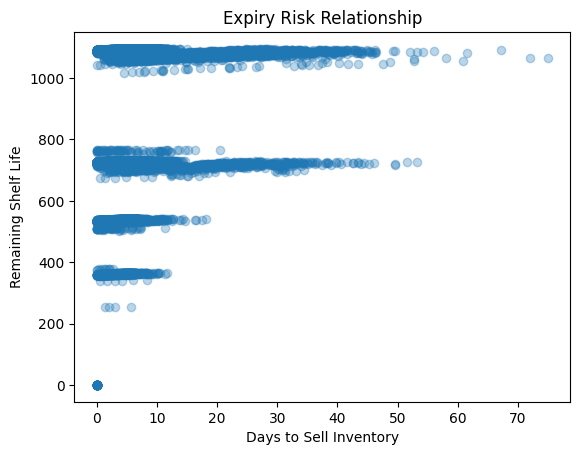

In [ ]:
plt.scatter(df["days_to_sell_inventory"], df["avg_remaining_shelf_life_days"], alpha=0.3)
plt.xlabel("Days to Sell Inventory")
plt.ylabel("Remaining Shelf Life")
plt.title("Expiry Risk Relationship")
plt.show()

# Correlation Matrix

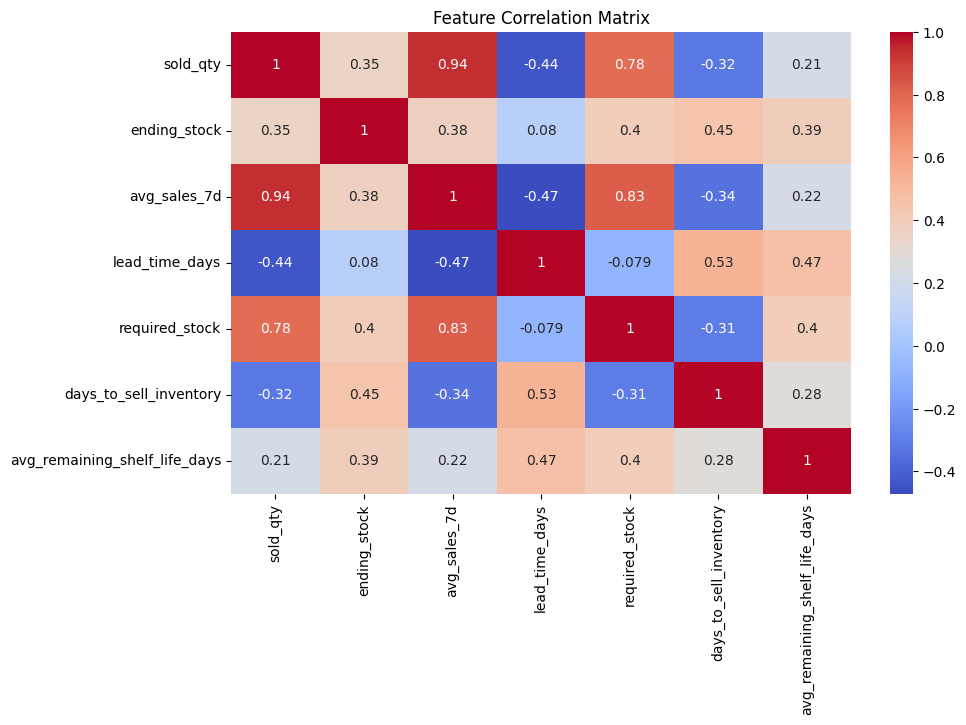

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df[[
    "sold_qty",
    "ending_stock",
    "avg_sales_7d",
    "lead_time_days",
    "required_stock",
    "days_to_sell_inventory",
    "avg_remaining_shelf_life_days"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

# Business Insight Checks
## Understock situations

In [ ]:
(df["ending_stock"] < df["required_stock"]).mean()

np.float64(0.4743888888888889)

## Overstock / Expiry risk

In [ ]:
(df["ending_stock"] > 2.0 * df["required_stock"]).mean()

np.float64(0.17327777777777778)

# Category-level analysis

In [ ]:
df.groupby("category")["sold_qty"].mean().sort_values(ascending=False)

,sold_qty
category,
analgesics and antipyretics,49.758333
analgesics and anti-inflammatory,20.120000
antihistamines,17.160000
antihypertensives,16.250000
antibiotics,13.079583
vitamins and supplements,11.907500
lipid-lowering agents,10.900000
gastrointestinal,10.230833
cough and cold,9.820000


In [ ]:
df.groupby("category")["ending_stock"].mean().sort_values(ascending=False)

,ending_stock
category,
analgesics and antipyretics,121.503333
antihypertensives,78.275000
analgesics and anti-inflammatory,68.580000
lipid-lowering agents,58.573333
vitamins and supplements,56.869722
endocrine,56.173333
antihistamines,50.897500
antibiotics,43.585833
antidiabetics,42.151111


# Seasonality check

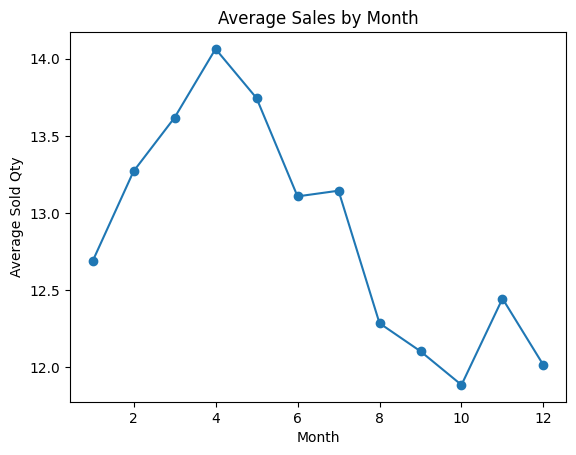

In [ ]:
df["month"] = df["date"].dt.month

df.groupby("month")["sold_qty"].mean().plot(kind="line", marker="o")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sold Qty")
plt.show()

# Outlier Detection

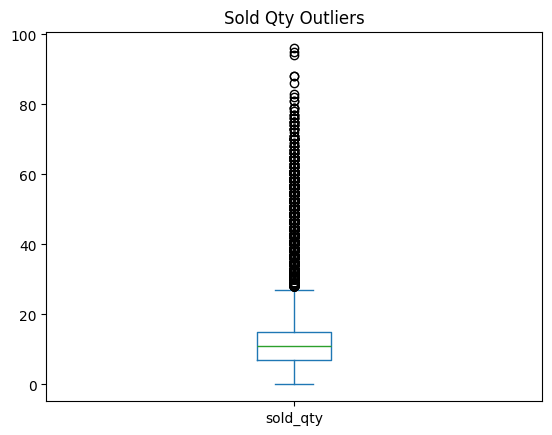

In [ ]:
df["sold_qty"].plot.box()
plt.title("Sold Qty Outliers")
plt.show()

# Create `risk_class`
**Logic recap:**
*   Understock → not enough stock for demand during lead time
*   Overstock → stock may expire before being sold
*   Balanced → everything else




In [ ]:
def classify_risk(row):
    if row["ending_stock"] < row["required_stock"]:
        return "understock"
    elif (
        row["ending_stock"] > 1.8 * row["required_stock"]
        or row["days_to_sell_inventory"] > 0.2 * row["avg_remaining_shelf_life_days"]
    ):
        return "overstock"
    else:
        return "balanced"

df["risk_class"] = df.apply(classify_risk, axis=1)

## Check distribution

In [ ]:
df["risk_class"].value_counts()
df["risk_class"].value_counts(normalize=True)

,proportion
risk_class,
understock,0.474389
balanced,0.310167
overstock,0.215444


# Training classification model for `risk_class`
## Select features and target
Since `sold_qty` and `avg_sales_7d` are highly correlated, use `avg_sales_7d` and drop `sold_qty` for now.


In [ ]:
feature_cols = [
    "ending_stock",
    "avg_sales_7d",
    "lead_time_days",
    "required_stock",
    "days_to_sell_inventory",
    "avg_remaining_shelf_life_days"
]

target_col = "risk_class"

X = df[feature_cols].copy()
y = df[target_col].copy()

print(X.shape)
print(y.shape)
print(y.value_counts())

(18000, 6)
(18000,)
risk_class
understock    8539
balanced      5583
overstock     3878
Name: count, dtype: int64


## Train/test split
Use **stratify=y** so class proportions stay similar in train and test.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (14400, 6) (14400,)
Test shape: (3600, 6) (3600,)


## Train the Random Forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

Why these settings?
* `n_estimators=200`: enough trees for stability
* `max_depth=10`: controls overfitting
* `min_samples_split` and `min_samples_leaf`: smoother rules
* `class_weight="balanced"`: helps if classes are not perfectly even

## Make predictions

In [ ]:
y_pred = clf.predict(X_test)

## Evaluate the model
### Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9969444444444444


### Classification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    balanced       0.99      1.00      1.00      1117
   overstock       1.00      1.00      1.00       775
  understock       1.00      1.00      1.00      1708

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600



## Confusion matrix
* diagonal = correct predictions
* off-diagonal = mistakes

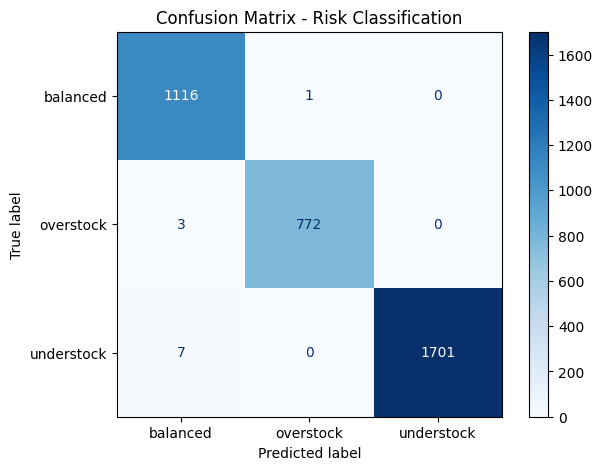

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Risk Classification")
plt.show()

## Feature importance

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                         feature  importance
4         days_to_sell_inventory    0.451443
0                   ending_stock    0.180798
2                 lead_time_days    0.136291
3                 required_stock    0.111701
1                   avg_sales_7d    0.081324
5  avg_remaining_shelf_life_days    0.038443


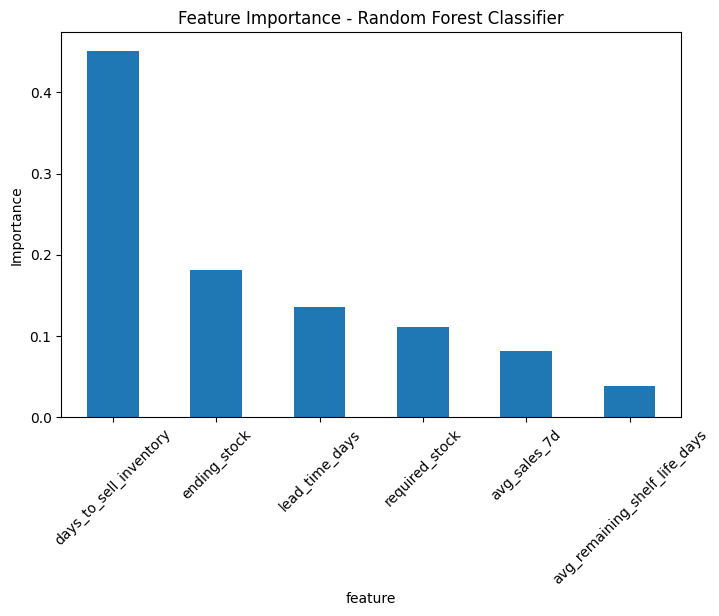

In [ ]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)
plt.title("Feature Importance - Random Forest Classifier")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

## Quick overfitting check

In [ ]:
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9986111111111111
Test Accuracy: 0.9969444444444444


## Try a baseline model for comparison

In [ ]:
from sklearn.tree import DecisionTreeClassifier

baseline_clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

baseline_clf.fit(X_train, y_train)
baseline_pred = baseline_clf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.9516666666666667
              precision    recall  f1-score   support

    balanced       0.89      0.97      0.93      1117
   overstock       0.96      0.97      0.96       775
  understock       1.00      0.93      0.96      1708

    accuracy                           0.95      3600
   macro avg       0.95      0.96      0.95      3600
weighted avg       0.96      0.95      0.95      3600



## Save the trained model

In [ ]:
import joblib

joblib.dump(clf, "risk_class_random_forest.pkl")
print("Saved: risk_class_random_forest.pkl")

Saved: risk_class_random_forest.pkl


## Predict on new rows

In [ ]:
sample = X_test.head(5)
sample_pred = clf.predict(sample)

pd.DataFrame({
    "actual": y_test.head(5).values,
    "predicted": sample_pred
})

,actual,predicted
0,understock,understock
1,balanced,balanced
2,understock,understock
3,balanced,balanced
4,balanced,balanced


# Training regression model for `recommended_order_qty_next_day`

## Define features and target

In [ ]:
feature_cols = [
    "ending_stock",
    "avg_sales_7d",
    "lead_time_days",
    "required_stock",
    "days_to_sell_inventory",
    "avg_remaining_shelf_life_days"
]

target_col = "recommended_order_qty_next_day"

X = df[feature_cols].copy()
y = df[target_col].copy()

print(X.shape)
print(y.describe())

(18000, 6)
count    18000.000000
mean        20.372388
std         27.740146
min          0.000000
25%          0.000000
50%          8.440000
75%         32.440000
max        191.580000
Name: recommended_order_qty_next_day, dtype: float64


## Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

## Make predictions

In [ ]:
y_pred = reg.predict(X_test)

## Evaluate the model

### Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.48397514063604624
RMSE: 1.102318005769827
R² Score: 0.9984474672158715


### How to interpret
* MAE → average error in units (e.g., “off by 5 units”)
* RMSE → penalizes big errors
* R²:
> * 1.0 = perfect
> * 0.9 = very strong
> * 0.7–0.9 = good
> * <0.5 = weak

**Expect:**
high R² (because target is also rule-based)
but not as perfect as classification

## Compare actual vs predicted

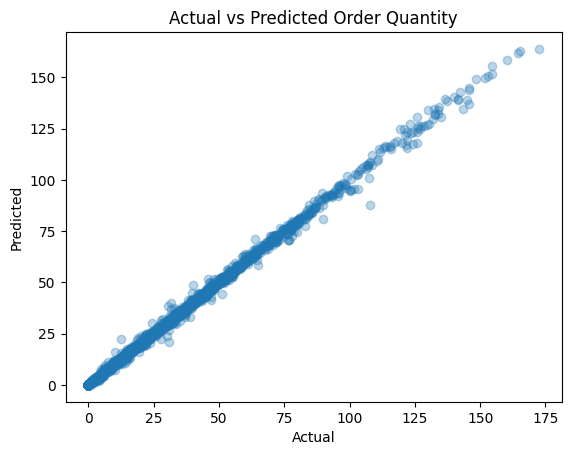

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Order Quantity")
plt.show()

## Residual analysis

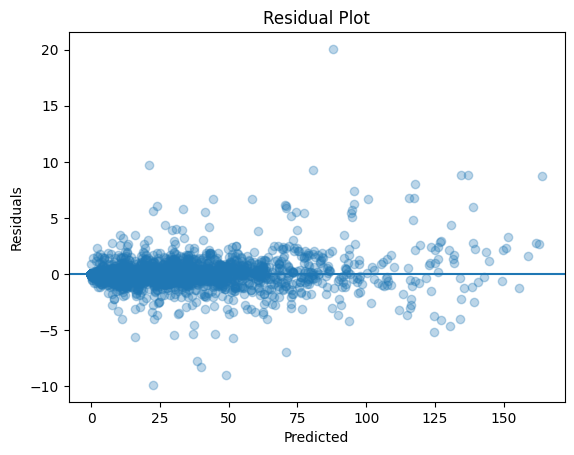

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Feature importance

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                         feature  importance
4         days_to_sell_inventory    0.660723
3                 required_stock    0.279182
2                 lead_time_days    0.034188
1                   avg_sales_7d    0.022857
0                   ending_stock    0.001877
5  avg_remaining_shelf_life_days    0.001174


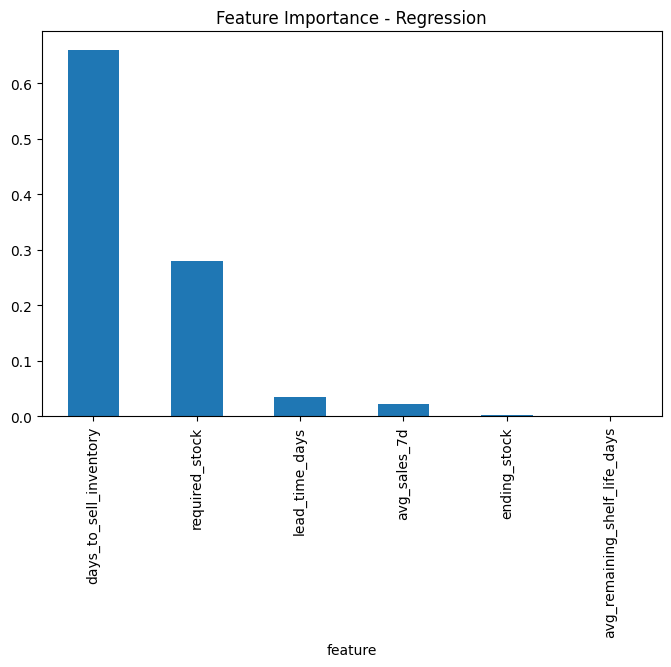

In [ ]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    figsize=(8,5)
)
plt.title("Feature Importance - Regression")
plt.show()

## Overfitting check

In [ ]:
train_r2 = reg.score(X_train, y_train)
test_r2 = reg.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.9991792469332379
Test R²: 0.9984474672158715


## Inspect predictions

In [ ]:
sample = X_test.copy()
sample["actual"] = y_test
sample["predicted"] = y_pred

sample.head(10)

,ending_stock,avg_sales_7d,lead_time_days,required_stock,days_to_sell_inventory,avg_remaining_shelf_life_days,actual,predicted
2574,38,7.57,2,15.14,5.02,538.61,0.00,0.000000
7496,35,4.86,5,24.29,7.20,727.10,0.00,0.000017
9210,6,17.29,5,86.43,0.35,1085.93,97.74,97.884278
5456,12,18.43,2,36.86,0.65,725.72,43.29,41.604588
736,29,11.57,4,46.29,2.51,725.11,28.85,29.318130
11770,70,15.71,5,78.57,4.46,1091.00,24.26,24.357444
856,49,10.71,4,42.86,4.58,723.45,4.55,4.477504
7273,16,7.86,5,39.29,2.04,725.09,31.16,29.820570
11499,155,18.57,5,92.86,8.35,1093.50,0.00,0.000013
11605,0,17.14,5,85.71,0.00,1084.33,102.84,102.234140


## Save model

In [ ]:
import joblib

joblib.dump(reg, "order_quantity_regressor.pkl")
print("Saved: order_quantity_regressor.pkl")

Saved: order_quantity_regressor.pkl


# Combined Decision System

## Load your trained models

In [ ]:
import joblib

clf = joblib.load("risk_class_random_forest.pkl")
reg = joblib.load("order_quantity_regressor.pkl")

## Prepare input data (same features as training)

In [ ]:
feature_cols = [
    "ending_stock",
    "avg_sales_7d",
    "lead_time_days",
    "required_stock",
    "days_to_sell_inventory",
    "avg_remaining_shelf_life_days"
]

## Create a “today snapshot”

In [ ]:
latest_df = df.sort_values("date").groupby("product_id").tail(1).copy()

latest_df.head()

,date,product_id,product_name,category,opening_stock,received_qty,sold_qty,lead_time_days,shelf_life_days,ending_stock,avg_sales_7d,required_stock,avg_remaining_shelf_life_days,days_to_sell_inventory,month,risk_class,target_stock,recommended_order_qty_next_day
8999,2026-08-23,P015,Oral Rehydration Salts Sachet,gastrointestinal,29,0,8,3,1095,21,9.43,28.29,1091.78,2.23,8,understock,37.72,16.72
16799,2026-08-23,P028,Dextromethorphan Syrup,cough and cold,17,0,8,3,540,9,8.86,26.57,533.81,1.02,8,understock,35.44,26.44
599,2026-08-23,P001,Amoxicillin 500mg Capsule,antibiotics,64,0,13,3,730,51,18.86,56.57,728.74,2.70,8,understock,75.44,24.44
1199,2026-08-23,P002,Azithromycin 500mg Tablet,antibiotics,55,0,15,4,730,40,13.14,52.57,720.26,3.04,8,understock,65.70,25.70
1799,2026-08-23,P003,Cefalexin 500mg Capsule,antibiotics,36,0,7,4,730,29,9.29,37.14,725.89,3.12,8,understock,46.45,17.45


## Run predictions

In [ ]:
X_latest = latest_df[feature_cols]

latest_df["predicted_risk"] = clf.predict(X_latest)
latest_df["predicted_order_qty"] = reg.predict(X_latest)

## Apply business decision rules
Now we turn predictions into actions.

In [ ]:
def decision_rule(row):
    if row["predicted_risk"] == "understock":
        return f"Order {round(row['predicted_order_qty'])} units"

    elif row["predicted_risk"] == "overstock":
        return "Do NOT order (reduce stock / monitor expiry)"

    else:
        return "No immediate action needed"

latest_df["recommended_action"] = latest_df.apply(decision_rule, axis=1)

## Final decision table

In [ ]:
decision_cols = [
    "product_id",
    "product_name",
    "category",
    "ending_stock",
    "avg_sales_7d",
    "lead_time_days",
    "predicted_risk",
    "predicted_order_qty",
    "recommended_action"
]

decision_table = latest_df[decision_cols].sort_values("predicted_risk")

decision_table.head(10)

,product_id,product_name,category,ending_stock,avg_sales_7d,lead_time_days,predicted_risk,predicted_order_qty,recommended_action
8399,P014,Omeprazole 20mg Capsule,gastrointestinal,48,11.43,4,balanced,9.462802,No immediate action needed
12599,P021,Atorvastatin 20mg Tablet,lipid-lowering agents,66,10.29,6,balanced,6.021639,No immediate action needed
14399,P024,Vitamin D3 1000IU Softgel,vitamins and supplements,35,4.86,6,balanced,0.000017,No immediate action needed
13799,P023,Vitamin C 500mg Tablet,vitamins and supplements,112,29.86,3,balanced,7.311568,No immediate action needed
13199,P022,Multivitamins Capsule,vitamins and supplements,74,11.86,5,balanced,0.000214,No immediate action needed
17999,P030,Levothyroxine 50mcg Tablet,endocrine,53,2.86,7,overstock,0.000013,Do NOT order (reduce stock / monitor expiry)
7199,P012,Salbutamol Syrup 2mg/5mL,respiratory,82,11.00,4,overstock,0.000013,Do NOT order (reduce stock / monitor expiry)
5999,P010,Cetirizine 10mg Tablet,antihistamines,71,15.29,2,overstock,0.000000,Do NOT order (reduce stock / monitor expiry)
5399,P009,Mefenamic Acid 500mg Capsule,analgesics and anti-inflammatory,90,12.86,3,overstock,0.000424,Do NOT order (reduce stock / monitor expiry)
4199,P007,Paracetamol 500mg Tablet,analgesics and antipyretics,158,42.14,2,overstock,0.000000,Do NOT order (reduce stock / monitor expiry)


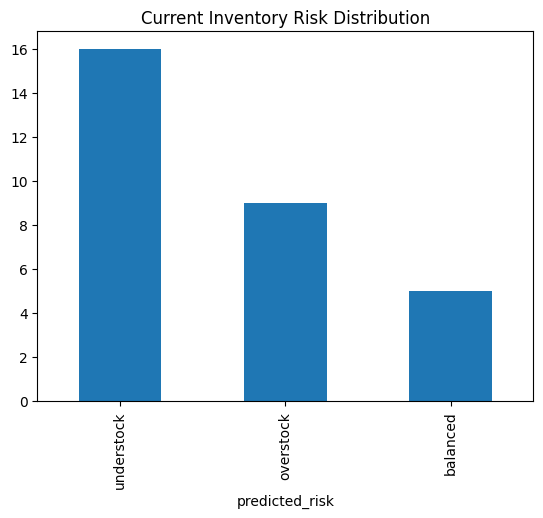

In [ ]:
import matplotlib.pyplot as plt

latest_df["predicted_risk"].value_counts().plot(kind="bar")
plt.title("Current Inventory Risk Distribution")
plt.show()

In [ ]:
decision_table.to_csv("daily_inventory_decisions.csv", index=False)
print("Saved: daily_inventory_decisions.csv")

Saved: daily_inventory_decisions.csv
